# Example of Linear Regression

## Import libraries and download dataset

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px



Here we will try to predict disease progression one year after baseline, for diabetic patients.

In [86]:
# Load the diabates dataset
from sklearn import datasets
X, y = datasets.load_diabetes(return_X_y=True, as_frame=True, scaled=False)

*Brief description:* Ten baseline variables, age, sex, body mass index, average blood pressure, and six blood serum measurements were obtained for each of n = 442 diabetes patients, as well as the response of interest, a quantitative measure of disease progression one year after baseline.

For more info, see: https://scikit-learn.org/stable/datasets/toy_dataset.html#:~:text=7.1.2.-,Diabetes%20dataset,progression%20one%20year%20after%20baseline.


## Let's briefly explore the dataset

- How many samples do we have?
- How many input features?
- Are there any categorical features?
- Are there NaN values?
- What is the range of the numerical features?
- Are the input features correlated between them?
- Are they correlated with the target variable?

In [87]:
X.shape

(442, 10)

In [88]:
X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000


In [90]:
nan_values = X.isna().sum()

print(nan_values)

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


In [ ]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


In [ ]:
X.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

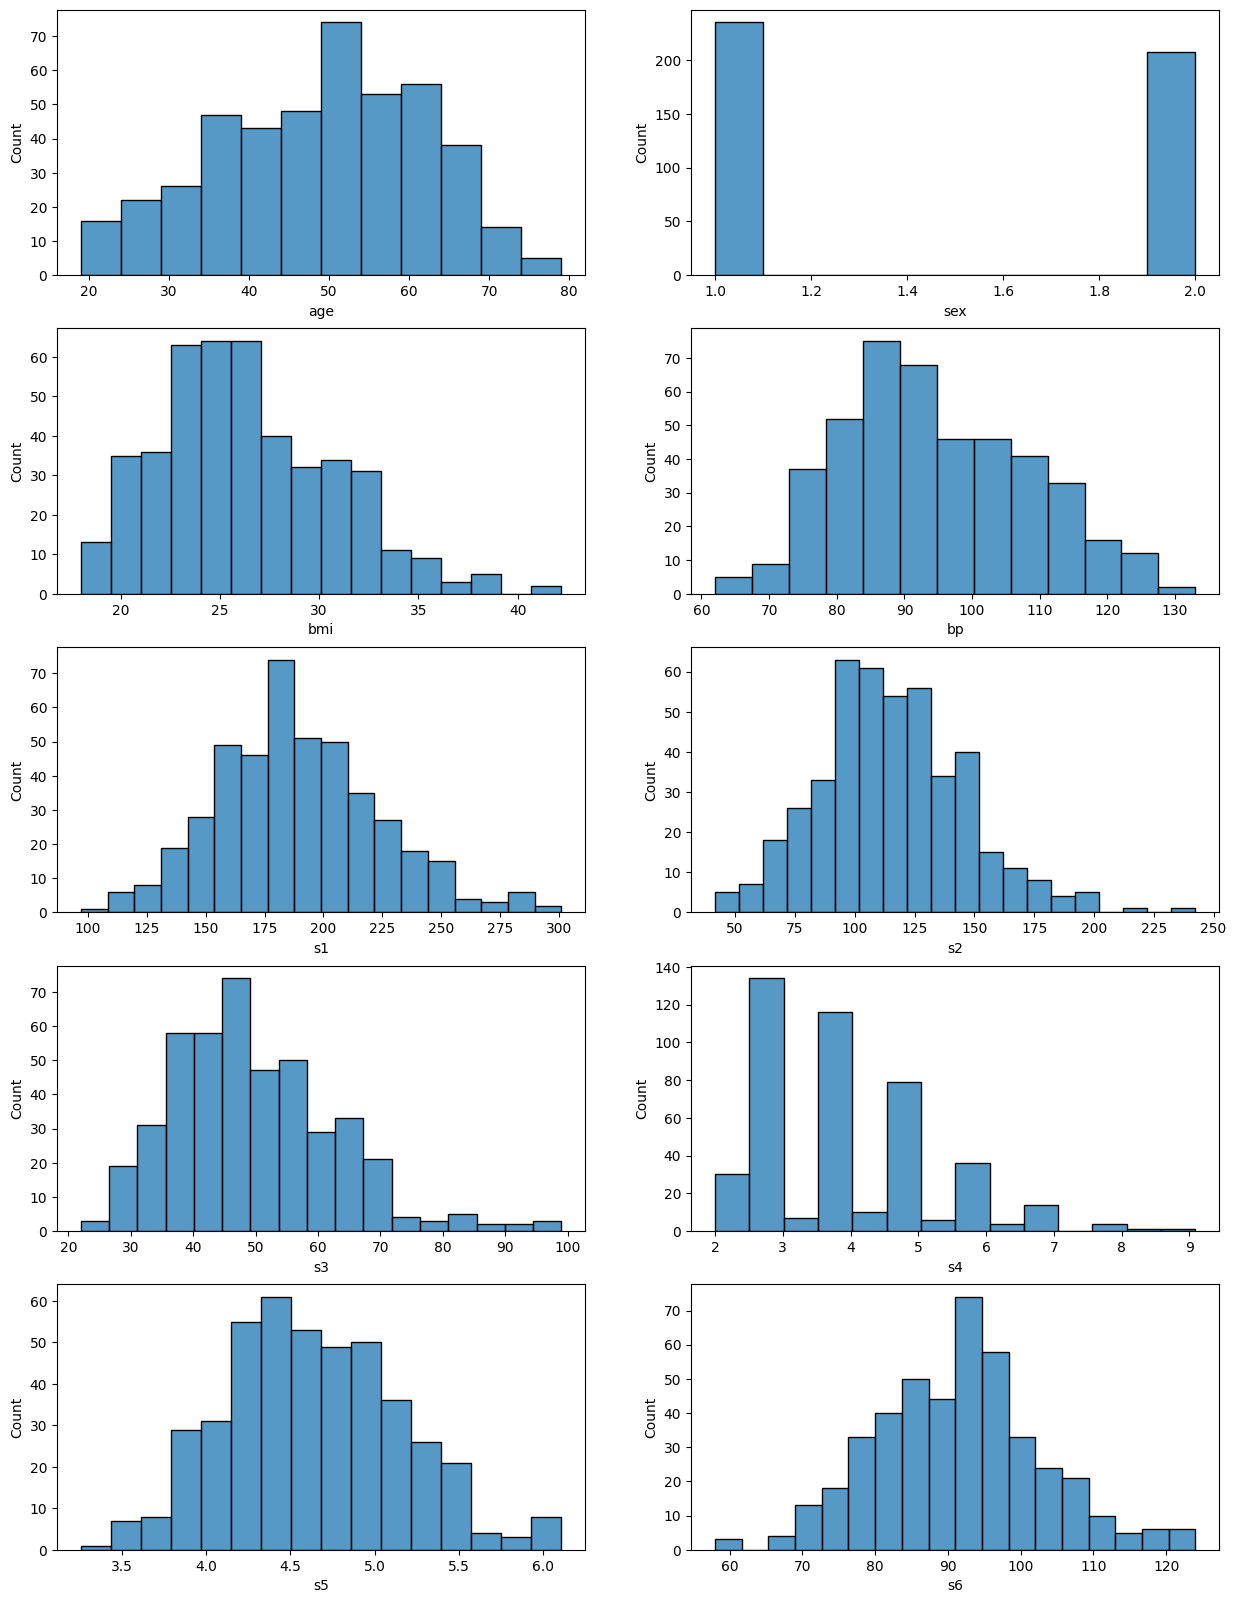

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
numerical_cols = X.columns

subx = 0
suby = 0
for i in numerical_cols:
  #create boxplot in each subplot
  sns.histplot(data=X, x=i, ax=axes[subx,suby])
  if suby == 0:
    suby = 1
  else:
    suby = 0
    subx = subx + 1

The second feature is boolean (it takes only two values), the histogram of the 8th feature needs more exploration, and the rest seem to have few outliers.

<Axes: xlabel='s4', ylabel='Count'>

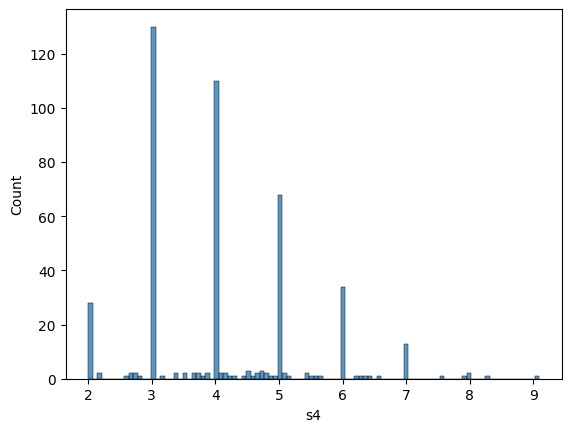

In [ ]:
sns.histplot(data=X, x='s4', bins=100)

## Let's prepare the data for Machine Learning

- Perform a 80/20 train-test split
- Normalize the input features if needed (minmax scaler or standarscaler)
- When normalizing input features, remember to do the `.fit_transform` on the train set BUT ONLY `.transform` on the test set!!

In [ ]:
# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

Given the information extracted from the previous section, we can transform all features with standarscaler, except 'sex'(boolean), and 's4'(minmax scaler seems more reasonable)


In [ ]:
# Sex column
X_train.replace({'sex': {1.0: 1.0, 2.0: 0.0}}, inplace=True) # Note that there are several ways to do this

In [ ]:
X_train

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
17,68.0,0.0,27.5,111.0,214.0,147.0,39.0,5.0,4.9416,91.0
66,46.0,0.0,24.7,85.0,174.0,123.2,30.0,6.0,4.6444,96.0
137,50.0,1.0,31.0,123.0,178.0,105.0,48.0,4.0,4.8283,88.0
245,41.0,1.0,23.1,86.0,148.0,78.0,58.0,3.0,4.0943,60.0
31,42.0,1.0,20.3,71.0,161.0,81.2,66.0,2.0,4.2341,81.0
...,...,...,...,...,...,...,...,...,...,...
106,22.0,1.0,19.3,82.0,156.0,93.2,52.0,3.0,3.9890,71.0
270,50.0,0.0,29.2,119.0,162.0,85.2,54.0,3.0,4.7362,95.0
348,57.0,1.0,24.5,93.0,186.0,96.6,71.0,3.0,4.5218,91.0
435,45.0,1.0,24.2,83.0,177.0,118.4,45.0,4.0,4.2195,82.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
s4_scaled = min_max_scaler.fit_transform(X_train['s4'].to_numpy().reshape(-1, 1))

Note: The `reshape(-1, 1)` function is used to convert the shape of the array that the `fit_transform` method operates on.

The `fit_transform` method of the `MinMaxScaler` expects its input to be a 2D array. However, when you select a single column from a pandas DataFrame (like `X_train['s4']`), it returns a 1D array. Thus, you need to reshape this 1D array into a 2D array before you can pass it to the `fit_transform` method.

`.reshape(-1, 1)` does exactly this. The -1 in reshape function is a placeholder for "whatever dimension is needed" and 1 is the size of the second dimension.

So, reshape(-1, 1) changes the shape of the array to have as many rows as needed (which will be the same number of rows as the original array) and 1 column. This way, you get a 2D array with a single column, which is what `fit_transform` expects.

In [ ]:
X_train.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

X_num = X_train[['age', 'bmi', 'bp', 's1', 's2', 's3', 's5', 's6']]
std_scaler = StandardScaler()
X_num_scaled = std_scaler.fit_transform(X_num)

In [ ]:
# Let's put everything back into a dataframe
df_s4_scaled = pd.DataFrame(s4_scaled, index=X_train.index, columns=['s4'])
df_X_num_scaled = pd.DataFrame(X_num_scaled, index=X_num.index, columns=X_num.columns)
# We also have X_train['sex']

In [ ]:
df_train = pd.concat([df_s4_scaled, df_X_num_scaled, X_train['sex']], axis=1)

In [ ]:
df_train

,s4,age,bmi,bp,s1,s2,s3,s5,s6,sex
17,0.423131,1.498365,0.219902,1.138874,0.728473,1.055893,-0.824451,0.547482,-0.061449,0.0
66,0.564175,-0.228858,-0.419366,-0.710591,-0.424929,0.272425,-1.529791,-0.019757,0.367236,0.0
137,0.282087,0.085182,1.018987,1.992473,-0.309589,-0.326699,-0.119111,0.331237,-0.318660,1.0
245,0.141044,-0.621409,-0.784662,-0.639458,-1.174640,-1.215508,0.664600,-1.069682,-2.719299,1.0
31,0.000000,-0.542899,-1.423930,-1.706457,-0.799784,-1.110167,1.291569,-0.802859,-0.918820,1.0
...,...,...,...,...,...,...,...,...,...,...
106,0.141044,-2.113102,-1.652240,-0.923991,-0.943960,-0.715141,0.194374,-1.270659,-1.776191,1.0
270,0.141044,0.085182,0.608029,1.707940,-0.770949,-0.978492,0.351116,0.155454,0.281499,0.0
348,0.141044,0.634754,-0.465028,-0.141525,-0.078908,-0.603217,1.683425,-0.253752,-0.061449,1.0
435,0.282087,-0.307368,-0.533521,-0.852858,-0.338424,0.114414,-0.354224,-0.830724,-0.833083,1.0


## Let's fit some Linear models to the training set

Fit a Linear Regression model without regularization

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(df_train, y_train)

LinearRegression()

What should the dimension of parameter vector $\theta$ be in this case?

In [ ]:
df_train.shape # 10 columns (i.e., input features/variables)

(353, 10)

In [ ]:
# We should have 10 plus the intercept
print(lin_reg.coef_)
print(lin_reg.intercept_)

[ 72.03113268   1.75375799  25.60712144  16.82887167 -44.44885564
  24.64095356   7.67697768  35.16119521   2.35136365  23.06446772]
120.38181012102304


Fit a Linear Regression model with L2 regularization (Ridge), with regularization parameter = 1.2

In [ ]:
from sklearn.linear_model import Ridge

lin_ridge = Ridge(alpha = 1.4)
lin_ridge.fit(df_train, y_train)

Ridge(alpha=1.4)

Compare the MAE of both models on the train set

In [ ]:
# MAE
from sklearn.metrics import mean_absolute_error

y_pred_train_lin_reg = lin_reg.predict(df_train)
y_pred_train_ridge = lin_ridge.predict(df_train)

mae_train_lin_reg = mean_absolute_error(y_pred_train_lin_reg, y_train)
mae_train_ridge = mean_absolute_error(y_pred_train_ridge, y_train)

print(mae_train_lin_reg)
print(mae_train_ridge)

43.483503523980396
43.57762604058433


## Evaluate the models on the test set

In [ ]:
# Compute the prediction error (MAE) of both models on the test set
# Remember you may need to make some transformations on the test set before making predictions

# Sex column
X_test.replace({'sex': {1.0: 1.0, 2.0: 0.0}}, inplace=True)

# s4 column
s4_scaled_test = min_max_scaler.transform(X_test['s4'].to_numpy().reshape(-1, 1)) # only TRANSFORM!!

# remaining num columns
X_num = X_test[['age', 'bmi', 'bp', 's1', 's2', 's3', 's5', 's6']]
X_num_scaled_test = std_scaler.transform(X_num) # only TRANSFORM!!

# Back into dataframe
df_s4_scaled_test = pd.DataFrame(s4_scaled_test, index=X_test.index, columns=['s4'])
df_X_num_scaled_test = pd.DataFrame(X_num_scaled_test, index=X_num.index, columns=X_num.columns)
df_test = pd.concat([df_s4_scaled_test, df_X_num_scaled_test, X_test['sex']], axis=1)

In [ ]:
y_pred_test_lin_reg = lin_reg.predict(df_test)
y_pred_test_ridge = lin_ridge.predict(df_test)


mae_test_lin_reg = mean_absolute_error(y_pred_test_lin_reg, y_test)
mae_test_ridge = mean_absolute_error(y_pred_test_ridge, y_test)

print(mae_test_lin_reg)
print(mae_test_ridge)

42.79409467959994
42.79168920125384


# Finding the best value of regularization parameter $\alpha$ via CV

**1) Using GridSearch CV**

In [ ]:
# Import libraries
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import KFold

In [ ]:
# Define the hyperparameters
alpha_values = np.logspace(-4, 4, 100)
param_grid = {'alpha': alpha_values}

In [ ]:
# Initialize a Ridge regressor
ridge = Ridge()

# Initialize a 3-fold CV grid search
grid = GridSearchCV(ridge, param_grid, cv=KFold(n_splits=3))

# Fit it with the data
grid.fit(df_train, y_train)

# Print the best hyperparameters
print('Best parameters found by grid search:', grid.best_params_)

Best parameters found by grid search: {'alpha': np.float64(0.09770099572992257)}


In [ ]:
from pandas import DataFrame

# Create a DataFrame from cv_results_
cv_results = DataFrame(grid.cv_results_)

In [ ]:
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003870,0.000289,0.002258,0.000377,0.000100,{'alpha': 0.0001},0.532206,0.530322,0.401119,0.487882,0.061356,42
1,0.002283,0.000081,0.001831,0.000119,0.000120,{'alpha': 0.00012045035402587823},0.532206,0.530322,0.401119,0.487883,0.061356,41
2,0.002226,0.000025,0.001711,0.000009,0.000145,{'alpha': 0.000145082877849594},0.532206,0.530322,0.401120,0.487883,0.061355,40
3,0.002775,0.000188,0.001777,0.000022,0.000175,{'alpha': 0.0001747528400007683},0.532205,0.530322,0.401120,0.487883,0.061355,39
4,0.002574,0.000419,0.002009,0.000421,0.000210,{'alpha': 0.00021049041445120198},0.532205,0.530322,0.401121,0.487883,0.061355,38


In [ ]:
cv_results.loc[cv_results['rank_test_score']==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
37,0.002248,0.000017,0.00167,0.000018,0.097701,{'alpha': 0.09770099572992257},0.531602,0.530024,0.402196,0.487941,0.060634,1


In [ ]:
# Print the table with alpha, mean_test_score (MSE), and std_test_score
tmp = cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'rank_test_score']]
tmp.head()

,param_alpha,mean_test_score,std_test_score,rank_test_score
0,0.000100,0.487882,0.061356,42
1,0.000120,0.487883,0.061356,41
2,0.000145,0.487883,0.061355,40
3,0.000175,0.487883,0.061355,39
4,0.000210,0.487883,0.061355,38


**2) Using Randomized Search CV**

In [ ]:
# Define the probability to draw alpha values from
from scipy.stats import uniform

# Define the hyperparameters
param_dist = {'alpha': uniform(loc=0, scale=4)}  # alpha will range from loc to loc + scale uniformly

from scipy.stats import loguniform

# Define the hyperparameters
param_dist = {'alpha': loguniform(1e-4, 1e4)} # generates a distribution in a logarithmic scale between 1e-4 and 1e4

In [ ]:
# Initialize a Ridge regressor
ridge = Ridge()

# Initialize a 3-fold CV randomized search
random_search = RandomizedSearchCV(ridge, param_distributions=param_dist, n_iter=100, cv=KFold(n_splits=3)) # n_iter specifies how many values to try

# Fit it with the data
random_search.fit(df_train, y_train)

# Print the best hyperparameters
print('Best parameters found by randomized search:', random_search.best_params_)

Best parameters found by randomized search: {'alpha': np.float64(0.11532207189549018)}


In [ ]:
random_search_results = DataFrame(random_search.cv_results_)

In [ ]:
random_search_results.loc[random_search_results['rank_test_score']==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
90,0.002948,0.000023,0.002258,0.000037,0.115322,{'alpha': 0.11532207189549018},0.5315,0.529962,0.402353,0.487938,0.060521,1


RETRAIN the model with the best alpha

In [ ]:
lin_ridge = Ridge(alpha = 0.115322)
lin_ridge.fit(df_train, y_train)

Ridge(alpha=0.115322)

In [ ]:
y_pred_test_opt_ridge = lin_ridge.predict(df_test)

In [ ]:
print(mean_absolute_error(y_pred_test_opt_ridge, y_test))

42.78973478548315
